In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
df = pd.read_excel('updated_marks_integers.xlsx', sheet_name='CO_End', header=0)
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [ ]:
print('=== Missing Value Report ===')
print(df.isnull().sum())
print(f'\nTotal rows : {len(df)}')
print(f'Rows with ALL marks missing: {df[df.isnull().any(axis=1)].shape[0]}')
print('\nStudents with missing data:')
df[df.isnull().any(axis=1)][['Batch','SAPID','Student Name']]

=== Missing Value Report ===
Batch           0
SAPID           0
Student Name    0
Q1(4)           4
Q2(4)           4
Q3(4)           4
Q4(4)           4
Q5(4)           4
Q6(10)          4
Q7(10)          4
Q8(10)          4
Q9(10)          4
Q10(20)         4
Q11(20)         4
Total(100)      4
dtype: int64

Total rows : 93
Rows with ALL marks missing: 4

Students with missing data:


,Batch,SAPID,Student Name
27,B10,590017810,Utkarsh Sangwan
79,B12,590015060,Ayush Rawat
89,B12,590018359,Kritika Kalra
92,B12,590019054,Ishan Chauhan


In [ ]:

score_cols = ['Q1(4)','Q2(4)','Q3(4)','Q4(4)','Q5(4)',
              'Q6(10)','Q7(10)','Q8(10)','Q9(10)','Q10(20)','Q11(20)','Total(100)']

df[score_cols] = df[score_cols].fillna(0)

print('Missing values after imputation:')
print(df.isnull().sum())
print('\nAll missing values resolved. Absent students treated as scoring 0.')

Missing values after imputation:
Batch           0
SAPID           0
Student Name    0
Q1(4)           0
Q2(4)           0
Q3(4)           0
Q4(4)           0
Q5(4)           0
Q6(10)          0
Q7(10)          0
Q8(10)          0
Q9(10)          0
Q10(20)         0
Q11(20)         0
Total(100)      0
dtype: int64

All missing values resolved. Absent students treated as scoring 0.


In [ ]:

feature_cols = ['Q1(4)','Q2(4)','Q3(4)','Q4(4)','Q5(4)',
                'Q6(10)','Q7(10)','Q8(10)','Q9(10)','Q10(20)','Q11(20)']

X = df[feature_cols].values.astype(float)


X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1  
X_norm = (X - X_min) / X_range

print('Feature matrix shape:', X_norm.shape)
print('Normalization complete — all features scaled to [0, 1]')

Feature matrix shape: (93, 11)
Normalization complete — all features scaled to [0, 1]


In [ ]:
def kmeans(X, k=3, max_iter=300, n_init=10, seed=42):
    """K-Means clustering from scratch with multiple restarts."""
    best_inertia = np.inf
    best_labels = None
    best_centers = None
    rng = np.random.RandomState(seed)

    for _ in range(n_init):
        
        idx = rng.choice(len(X), k, replace=False)
        centers = X[idx].copy()

        for iteration in range(max_iter):
        
            dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
            labels = np.argmin(dists, axis=1)

        
            new_centers = np.array([
                X[labels == j].mean(axis=0) if (labels == j).any() else centers[j]
                for j in range(k)
            ])

            if np.allclose(centers, new_centers):
                break
            centers = new_centers

        inertia = sum(
            np.sum((X[labels == j] - centers[j]) ** 2)
            for j in range(k)
        )
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels  = labels.copy()
            best_centers = centers.copy()

    return best_labels, best_centers, best_inertia

labels, centers, inertia = kmeans(X_norm, k=3, n_init=20, seed=42)
print('K-Means converged. Inertia:', round(inertia, 4))
print('Cluster sizes:', dict(zip(*np.unique(labels, return_counts=True))))

K-Means converged. Inertia: 47.9012
Cluster sizes: {np.int64(0): np.int64(34), np.int64(1): np.int64(23), np.int64(2): np.int64(36)}


In [ ]:
df['Cluster_Raw'] = labels

cluster_means = df.groupby('Cluster_Raw')['Total(100)'].mean()
rank_order = cluster_means.sort_values(ascending=False).index.tolist()

label_map = {
    rank_order[0]: 'High Performers',
    rank_order[1]: 'Average Performers',
    rank_order[2]: 'Low Performers'
}
df['Group'] = df['Cluster_Raw'].map(label_map)

print('Cluster → Group mapping:')
for raw, name in label_map.items():
    print(f'  Cluster {raw} → {name}  (mean Total = {cluster_means[raw]:.1f})')

Cluster → Group mapping:
  Cluster 1 → High Performers  (mean Total = 58.2)
  Cluster 0 → Average Performers  (mean Total = 39.9)
  Cluster 2 → Low Performers  (mean Total = 10.5)


In [ ]:
summary = df.groupby('Group')[score_cols].agg(['mean','min','max','std']).round(2)
print(summary.to_string())

                   Q1(4)                 Q2(4)                 Q3(4)                 Q4(4)                 Q5(4)                 Q6(10)                  Q7(10)                  Q8(10)                  Q9(10)                  Q10(20)                 Q11(20)                 Total(100)                   
                    mean  min  max   std  mean  min  max   std  mean  min  max   std  mean  min  max   std  mean  min  max   std   mean  min   max   std   mean  min   max   std   mean  min   max   std   mean  min   max   std    mean  min  max   std    mean  min  max   std       mean   min   max    std
Group                                                                                                                                                                                                                                                                                                         
Average Performers  2.97  0.0  6.0  1.80  2.97  0.0  6.0  1.88  3.41  0.0  6.0  1.28  2.88 

In [ ]:
for grp in ['High Performers', 'Average Performers', 'Low Performers']:
    g = df[df['Group'] == grp]
    print(f'\n{'='*55}')
    print(f' Group : {grp}  (n={len(g)})')
    print(f'{'='*55}')
    print(f'  Mean Total Score : {g["Total(100)"].mean():.1f} / 100')
    print(f'  Score Range      : {g["Total(100)"].min():.0f} – {g["Total(100)"].max():.0f}')
    print(f'  Std Dev          : {g["Total(100)"].std():.2f}')
    print(f'  Batches          : {sorted(g["Batch"].unique())}')

print()



 Group : High Performers  (n=23)
  Mean Total Score : 58.2 / 100
  Score Range      : 35 – 76
  Std Dev          : 12.36
  Batches          : ['B10', 'B11']

 Group : Average Performers  (n=34)
  Mean Total Score : 39.9 / 100
  Score Range      : 21 – 93
  Std Dev          : 15.89
  Batches          : ['B10', 'B11', 'B12']

 Group : Low Performers  (n=36)
  Mean Total Score : 10.5 / 100
  Score Range      : 0 – 36
  Std Dev          : 10.16
  Batches          : ['B10', 'B11', 'B12']



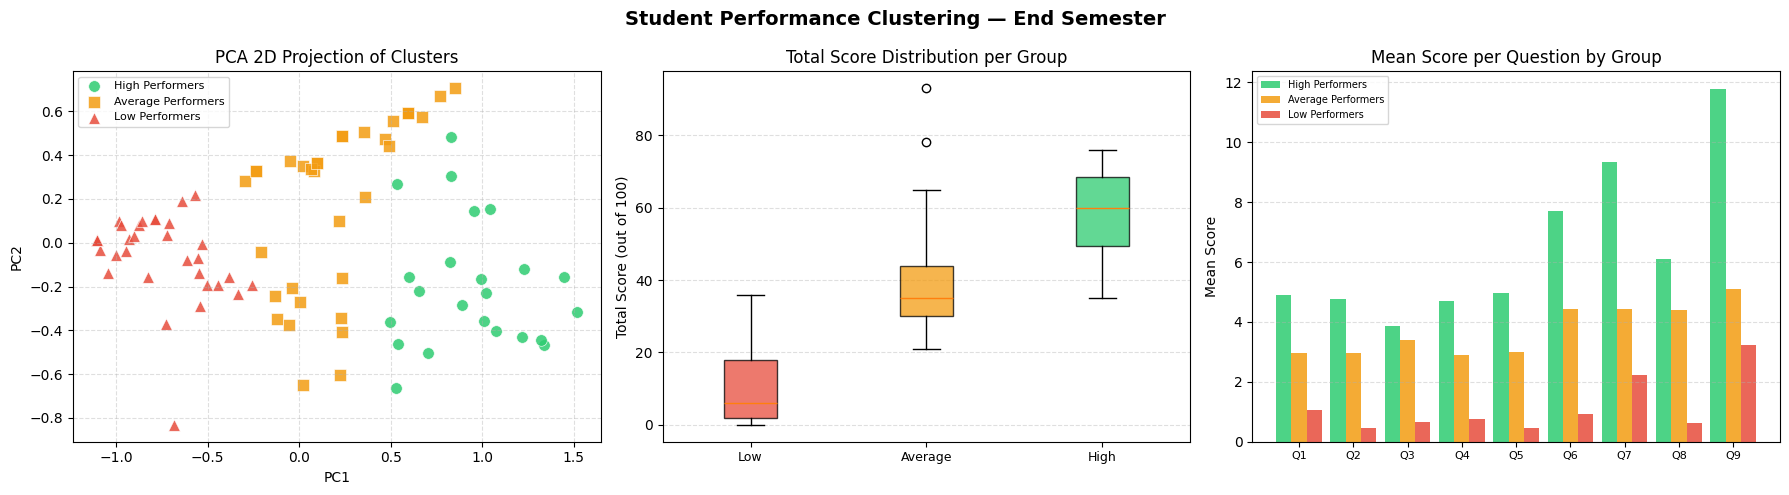

Plot saved as clustering_results.png


In [ ]:
# ── PCA projection (manual 2-component) ──────────────────────────
def manual_pca(X, n=2):
    X_c = X - X.mean(axis=0)
    cov = np.cov(X_c.T)
    vals, vecs = np.linalg.eigh(cov)
    idx = np.argsort(vals)[::-1][:n]
    return X_c @ vecs[:, idx]

X2 = manual_pca(X_norm)

colors = {'High Performers': '#2ecc71', 'Average Performers': '#f39c12', 'Low Performers': '#e74c3c'}
markers = {'High Performers': 'o', 'Average Performers': 's', 'Low Performers': '^'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Student Performance Clustering — End Semester', fontsize=14, fontweight='bold')

# --- Plot 1: PCA Scatter ---
ax = axes[0]
for grp, clr in colors.items():
    mask = df['Group'] == grp
    ax.scatter(X2[mask, 0], X2[mask, 1],
               c=clr, label=grp, marker=markers[grp],
               s=70, alpha=0.85, edgecolors='white', linewidths=0.5)
ax.set_title('PCA 2D Projection of Clusters')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

# --- Plot 2: Boxplot of Total Score ---
ax = axes[1]
grp_order = ['Low Performers', 'Average Performers', 'High Performers']
data_box = [df[df['Group'] == g]['Total(100)'].values for g in grp_order]
bp = ax.boxplot(data_box, patch_artist=True, notch=False)
box_colors = ['#e74c3c', '#f39c12', '#2ecc71']
for patch, clr in zip(bp['boxes'], box_colors):
    patch.set_facecolor(clr)
    patch.set_alpha(0.75)
ax.set_xticks([1,2,3])
ax.set_xticklabels(['Low','Average','High'], fontsize=9)
ax.set_title('Total Score Distribution per Group')
ax.set_ylabel('Total Score (out of 100)')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

# --- Plot 3: Bar — mean score per question per group ---
ax = axes[2]
q_cols = ['Q1(4)','Q2(4)','Q3(4)','Q4(4)','Q5(4)','Q6(10)','Q7(10)','Q8(10)','Q9(10)']
x = np.arange(len(q_cols))
width = 0.28
for i, (grp, clr) in enumerate(colors.items()):
    means = df[df['Group'] == grp][q_cols].mean().values
    ax.bar(x + i*width, means, width, label=grp, color=clr, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels([c.split('(')[0] for c in q_cols], fontsize=8)
ax.set_title('Mean Score per Question by Group')
ax.set_ylabel('Mean Score')
ax.legend(fontsize=7)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as clustering_results.png')

In [ ]:
output = df[['Batch','SAPID','Student Name','Total(100)','Group']].sort_values(
    ['Group','Total(100)'], ascending=[True, False]
).reset_index(drop=True)

print('=== FINAL CLUSTER ASSIGNMENT ===')
print(output.to_string(index=False))

output.to_excel('clustering_output.xlsx', index=False)
print('\nSaved to clustering_output.xlsx')

=== FINAL CLUSTER ASSIGNMENT ===
Batch     SAPID                  Student Name  Total(100)              Group
  B12 590017910                   Manya  Goel        93.0 Average Performers
  B12 590011529                    ARSH  JAIN        78.0 Average Performers
  B12 590013960                Meghna  Dhakad        65.0 Average Performers
  B12 590012061                Tanya  Marwaha        59.0 Average Performers
  B12 590014891                Samagra  Gupta        55.0 Average Performers
  B12 590016128               Pranav  Dwivedi        55.0 Average Performers
  B10 590013167                 KARTIK  TYAGI        50.0 Average Performers
  B11 590016337                     Rishika          46.0 Average Performers
  B11 590017455                  Shweta  Arya        44.0 Average Performers
  B12 590011800                 Ishika  Goyal        44.0 Average Performers
  B12 590015468                  Fagun  Wasan        42.0 Average Performers
  B10 590015877              Divyansh  Jind

In [ ]:
# Quick count per group
print('Students per group:')
print(df['Group'].value_counts())

Students per group:
Group
Low Performers        36
Average Performers    34
High Performers       23
Name: count, dtype: int64
